### **1- Modelamiento determinista**
Formule un modelo MILP completo, donde defina:

- **Conjuntos y parámetros**
- **Variables de decision**
- **Función Objetivo**
- **Restricciones**


**Escenario:** s = 1 (Normal), demanda determinista  
**Tipo de problema:** VRPTW multi-compartimento con entregas multi-producto, estabilidad de carga y shortage

### Conjuntos
<table>
  <thead>
    <tr><th>Símbolo</th><th>Definición</th></tr>
  </thead>
  <tbody>
    <tr>
      <td><b>V = {0} ∪ J</b></td>
      <td>Nodos del grafo. <b>0</b> = depósito de carga <b>D</b>; <b>J = {1,2,3,4}</b> = estaciones de servicio</td>
    </tr>
    <tr>
      <td><b>K = {1,2}</b></td>
      <td>Camiones (<b>1 ≡ T1</b>, <b>2 ≡ T2</b>)</td>
    </tr>
    <tr>
      <td><b>C = {0,1}</b></td>
      <td>Compartimentos por camión (<b>C0</b>, <b>C1</b>)</td>
    </tr>
    <tr>
      <td><b>G = {R,D}</b></td>
      <td>Gasolinas (<b>R</b> = Regular, <b>D</b> = Diésel)</td>
    </tr>
    <tr>
      <td><b>A = {(i,j) : i,j ∈ V, i ≠ j}</b></td>
      <td>Arcos dirigidos posibles (tramos posibles del viaje)</td>
    </tr>
    <tr>
      <td><b>J₂ = {(j₁,j₂) : j₁,j₂ ∈ J, j₁ ≠ j₂}</b></td>
      <td>Pares ordenados de estaciones distintas (define el orden de visita)</td>
    </tr>
  </tbody>
</table>

### Parámetros

| Parámetro | Descripción | Valor (s=1) |
|-----------|-------------|-------------|
| $dist_{ij}$ | Distancia del nodo $i$ al nodo $j$ (km) | Matriz del enunciado |
| $cost^{dist}$ | Costo por km recorrido (USD/km) | 2 |
| $cost^{short}$ | Penalización por litro no entregado (USD/L) | 10 |
| $cap_{kc}$ | Capacidad del compartimento $c$ del camión $k$ (L) | T1: 8000, 7000; T2: 6000, 9000 |
| $F_k$ | Costo fijo de usar el camión $k$ (USD) | T1: 500; T2: 400 |
| $vel$ | Velocidad de los camiones (km/h) | 60 |
| $T^{serv}$ | Tiempo de servicio en estación (h) | 0.5 (30 min) |
| $Dep_k$ | Hora de salida programada del camión $k$ (h) | T1: 5.0; T2: 5.5 |
| $a_j$, $b_j$ | Ventana de tiempo de la estación $j$ (h) | Ver tabla de demanda |
| $Dem_{jg}$ | Demanda de producto $G$ en estación $j$ (L) | Ver tabla de demanda |
| $\Delta$ | Máx. diferencia entre fill ratios del mismo camión | 0.30 |
| $Tasa_g$ | Tasa de carga del producto $G$ en depósito (L/min) | R: 500; D: 400 |
| $Bahia_g$ | Bahías disponibles por producto $G$ | 1 por producto |
| $T^{limp}$ | Tiempo de limpieza al terminar carga (min) | 5 |
| $M$ | Constante big-M (activar/desactivar restricciones binarias) | Valor grande |
| $\bar{W}$ | Cota superior de litros por tupla $(k,c,j)$ | ver nota abajo |

**Nota:** $\bar{W} = \min(Q_{kc}, D_{jR}+D_{jD})$

> $Tasa_g$, $Bahia_g$ y $T^{limp}$ pertenecen al **scheduling del depósito (Pregunta 2)**. Se listan aquí como parámetros globales del contexto, pero **no entran en las restricciones del MILP de ruteo (P1)**.

**Variables de decisión**

| Variable | Tipo | Interpretación |
|----------|------|----------------|
| $x_{ijk}$ | Binaria | $=1$ si el camión $k$ recorre el arco $(i,j)$ (con eso definimos la ruta del camión)|
| $util_k$ | Binaria | $=1$ si el camión $k$ es utilizado |
| $y_{kj}$ | Binaria | $=1$ si el camión $k$ visita la estación $j$ |
| $trans_{kcg}$ | Binaria | $=1$ si el compartimento $c$ del camión $k$ transporta producto $G$ |
| $Lts_{kcj}$ | Continua $\geq 0$ | Litros entregados por $(k,c)$ en estación $j$ |
| $\lambda_{kcjg}$ | Continua $\geq 0$ | Litros de producto $G$ entregados por $(k,c)$ en $j$ (linearización) (MILP no puede multiplicar variables directamente) |
| $L_{kc}$ | Continua $\geq 0$ | Carga inicial en $(k,c)$ al salir del depósito |
| $shortage_{jg}$ | Continua $\geq 0$ | Shortage de producto $G$ en estación $j$ |
| $T_{kj}$ | Continua $\geq 0$ | Tiempo de llegada del camión $k$ al nodo $j$ |
| $\sigma_{kj_1j_2}$ | Binaria | $=1$ si el camión $k$ visita $j_1$ **antes** que $j_2$ |
| $r_{kcj}$ | Continua $\geq 0$ | Inventario remanente en $(k,c)$ **después** de servir $j$ |

## Datos del enunciado

In [6]:
import pandas as pd

# Demanda y ventanas de tiempo — escenario s=1
demanda = pd.DataFrame({
    'Estación': [1, 2, 3, 4],
    'Regular (L)': [3000, 4000, 2500, 1000],
    'Diésel (L)': [2000, 1500, 3000, 2500],
    'Ventana inicio (h)': [6.0, 7.0, 8.0, 6.0],
    'Ventana fin (h)': [10.0, 12.0, 14.0, 11.0],
})

flota = pd.DataFrame({
    'Camión': ['T1', 'T2'],
    'Cap. C0 (L)': [8000, 6000],
    'Cap. C1 (L)': [7000, 9000],
    'Costo fijo ($)': [500, 400],
    'Hora salida (h)': [5.0, 5.5],
})

nodos = ['Depósito', 'E1', 'E2', 'E3', 'E4']
dist = pd.DataFrame([
    [0,   20, 35, 15, 40],
    [20,  0,  10, 25, 30],
    [35,  10, 0,  20, 15],
    [15,  25, 20, 0,  30],
    [40,  30, 15, 30, 0],
], columns=nodos, index=nodos)

carga_deposito = pd.DataFrame({
    'Producto': ['Regular (R)', 'Diésel (D)'],
    'Tasa carga (L/min)': [500, 400],
    'Bahías disponibles': [1, 1],
    'Limpieza al terminar (min)': [5, 5],
})

print('=== DEMANDA Y VENTANAS ===')
display(demanda)
print('\n=== CAMIONES ===')
display(flota)
print('\n=== MATRIZ DE DISTANCIAS (km) ===')
display(dist)
print('\n=== PARÁMETROS DE CARGA EN EL DEPÓSTO ===')
display(carga_deposito)

=== DEMANDA Y VENTANAS ===


,Estación,Regular (L),Diésel (L),Ventana inicio (h),Ventana fin (h)
0,1,3000,2000,6.0,10.0
1,2,4000,1500,7.0,12.0
2,3,2500,3000,8.0,14.0
3,4,1000,2500,6.0,11.0



=== CAMIONES ===


,Camión,Cap. C0 (L),Cap. C1 (L),Costo fijo ($),Hora salida (h)
0,T1,8000,7000,500,5.0
1,T2,6000,9000,400,5.5



=== MATRIZ DE DISTANCIAS (km) ===


,Depósito,E1,E2,E3,E4
Depósito,0,20,35,15,40
E1,20,0,10,25,30
E2,35,10,0,20,15
E3,15,25,20,0,30
E4,40,30,15,30,0



=== PARÁMETROS DE CARGA EN EL DEPÓSTO ===


,Producto,Tasa carga (L/min),Bahías disponibles,Limpieza al terminar (min)
0,Regular (R),500,1,5
1,Diésel (D),400,1,5


**Función objetivo**

$$
\min Z = Z^{dist} + Z^{fijo} + Z^{short}
$$

**Costo por distancia:**
$$
Z^{dist} = cost^{dist} \sum_{k \in K} \sum_{(i,j) \in A} dist_{ij}\, x_{ijk}
$$

**Costo fijo por camión:**
$$
Z^{fijo} = \sum_{k \in K} F_k\, util_k
$$

**Penalización por shortage:**
$$
Z^{short} = cost^{short} \sum_{j \in J} \sum_{g \in G} shortage_{jg}
$$

#**Restricciones**

**1. camiones y  rutas**

$$
\sum_{j \in J} x_{0jk} = util_k \qquad \forall k \in K
\quad \text{(si se usa el camión, sale del depósito)}
$$

$$
\sum_{i \in J} x_{i0k} = util_k \qquad \forall k \in K
\quad \text{(si se usa el camión, vuelve al depósito)}
$$

**2. Conservación de flujo**

$$
\sum_{i \in V} x_{ijk} = \sum_{\ell \in V} x_{j\ell k}
\qquad \forall k \in K,\; \forall j \in J
$$

$$
\sum_{i \in V} x_{ijk} = y_{kj}
\qquad \forall k \in K,\; \forall j \in J
$$

$$
\sum_{k \in K} y_{kj} \geq 1
\qquad \forall j \in J
\quad \text{(opcional: cada estación recibe al menos una visita)}
$$

**3. Eliminación de subtours (MTZ) y tiempos**

$$
T_{kj} \geq T_{ki} + T^{serv} + \frac{d_{ij}}{vel} - M(1 - x_{ijk})
\qquad \forall k,\; \forall i \neq j
$$

$$
T_{k0} = Dep_k \qquad \forall k \in K
$$

$$
T_{kj} \leq M\, y_{kj} \qquad \forall k,j
$$

**4. Ventanas de tiempo**

$$
T_{kj} \geq a_j - M(1 - y_{kj}) \qquad \forall k,j
$$

$$
T_{kj} \leq b_j + M(1 - y_{kj}) \qquad \forall k,j
$$



**5. Compatibilidad compartimento–producto**

$$
\sum_{g \in G} trans_{kcg} = 1
\qquad \forall k \in K,\; \forall c \in C
$$



**6. Entregas, linearización y demanda con shortage**<br><br>
**Carga inicial = total a entregar:**
$$
L_{kc} = \sum_{j \in J} Lts_{kcj} \qquad \forall k,c
$$

**Solo se entrega si hay visita:**
$$
Lts_{kcj} \leq \bar{W}\, y_{kj} \qquad \forall k,c,j
$$

**Linearización** $\lambda_{kcjg} = Lts_{kcj} \cdot trans_{kcg}$:
$$
\lambda_{kcjg} \leq \bar{W}\, trans_{kcg}, \quad
\lambda_{kcjg} \leq Lts_{kcj}, \quad
\lambda_{kcjg} \geq Lts_{kcj} - \bar{W}(1 - trans_{kcg})
$$

**Balance de demanda:**
$$
\sum_{k,c} \lambda_{kcjR} + shortage_{jR} = Dem_{jR}, \qquad
\sum_{k,c} \lambda_{kcjD} + shortage_{jD} = Dem_{jD} \qquad \forall j
$$

**7. Capacidad de compartimentos**

$$
L_{kc} \leq cap_{kc} \qquad \forall k,c
$$

$$
Lts_{kcj} \leq cap_{kc} \qquad \forall k,c,j
$$

**8. Orden de visitas (para estabilidad dinámica)**

$$
\sigma_{kj_1j_2} + \sigma_{kj_2j_1} \leq y_{kj_1}
$$

$$
\sigma_{kj_1j_2} + \sigma_{kj_2j_1} \leq y_{kj_2}
$$

$$
\sigma_{kj_1j_2} + \sigma_{kj_2j_1} \geq y_{kj_1} + y_{kj_2} - 1
$$

**Consistencia con tiempos:**
$$
T_{kj_2} \geq T_{kj_1} + T^{serv} + \frac{d_{j_1j_2}}{v} - M(1 - \sigma_{kj_1j_2})
$$

**9. Estabilidad de carga ($\Delta = 0.30$)**

**Inventario remanente** después de servir $j$:

Linearización $\vartheta_{kj'j} = \sigma_{kj'j} \cdot y_{kj'}$:
$$
\vartheta_{kj'j} \leq \sigma_{kj'j}, \quad
\vartheta_{kj'j} \leq y_{kj'}, \quad
\vartheta_{kj'j} \geq \sigma_{kj'j} + y_{kj'} - 1
$$

$$
r_{kcj} = L_{kc} - \sum_{j' \in J} \vartheta_{kj'j}\, Lts_{kcj'} - Lts_{kcj}
$$

**En el depósito:**
$$
\left|\frac{L_{kc}}{cap_{kc}} - \frac{L_{kc'}}{cap_{kc'}}\right| \leq \Delta
\qquad \forall k,\; c \neq c'
$$

**Después de cada estación visitada:**
$$
\left|\frac{r_{kcj}}{cap_{kc}} - \frac{r_{kc'j}}{cap_{kc'}}\right|
\leq \Delta + M(1 - y_{kj})
\qquad \forall k,j,\; c \neq c'
$$

###**1.1 Tabú search**

### Datos del problema

In [26]:
import random
import math
from copy import deepcopy
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
import pandas as pd

# --- Conjuntos ---
DEPOT = 0
STATIONS = [1, 2, 3, 4]
TRUCKS = [0, 1]          # 0=T1, 1=T2
TRUCK_NAMES = {0: 'T1', 1: 'T2'}
COMPARTS = [0, 1]        # C0, C1
PRODUCTS = ['R', 'D']    # Regular, Diésel

# --- Costos ---
COST_KM = 2
COST_SHORT = 10
FIXED_COST = {0: 500, 1: 400}

# --- Operación ---
SPEED = 60               # km/h
SERVICE_H = 0.5          # 30 min
DEPARTURE = {0: 5.0, 1: 5.5}   # horas (05:00, 05:30)
DELTA = 0.30             # estabilidad de carga

# --- Capacidades (L) ---
CAP = {
    (0, 0): 8000, (0, 1): 7000,
    (1, 0): 6000, (1, 1): 9000,
}

# --- Demanda (L): demand[j][p] ---
DEMAND = {
    1: {'R': 3000, 'D': 2000},
    2: {'R': 4000, 'D': 1500},
    3: {'R': 2500, 'D': 3000},
    4: {'R': 1000, 'D': 2500},
}

# --- Ventanas de tiempo [a, b] en horas ---
TIME_WINDOW = {
    1: (6.0, 10.0),
    2: (7.0, 12.0),
    3: (8.0, 14.0),
    4: (6.0, 11.0),
}

# --- Matriz de distancias (km) ---
NODES = [0, 1, 2, 3, 4]
DIST = {
    (0,1):20,(0,2):35,(0,3):15,(0,4):40,
    (1,0):20,(1,2):10,(1,3):25,(1,4):30,
    (2,0):35,(2,1):10,(2,3):20,(2,4):15,
    (3,0):15,(3,1):25,(3,2):20,(3,4):30,
    (4,0):40,(4,1):30,(4,2):15,(4,3):30,
}
for i in NODES:
    DIST[(i,i)] = 0

# Penalización por infactibilidad (para exploración)
PENALTY = 50_000

print('Datos cargados correctamente.')

Datos cargados correctamente.


### Representación de solución

In [27]:
@dataclass
class Solution:
    """Rutas, asignación de producto y entregas por compartimento."""
    routes: Dict[int, List[int]]              # camión -> [estaciones en orden]
    products: Dict[Tuple[int,int], str]       # (k,c) -> 'R' o 'D'
    deliveries: Dict[Tuple[int,int,int], float] = field(default_factory=dict)  # (k,c,j) -> litros
    used: Dict[int, bool] = field(default_factory=lambda: {0: True, 1: True})

    def copy(self):
        return deepcopy(self)


def route_distance(route: List[int]) -> float:
    """Distancia total D -> ruta -> D."""
    if not route:
        return 0.0
    total = DIST[(DEPOT, route[0])]
    for i in range(len(route) - 1):
        total += DIST[(route[i], route[i+1])]
    total += DIST[(route[-1], DEPOT)]
    return total


def compartment_load(sol: Solution, k: int, c: int) -> float:
    """Carga inicial = total entregado en la ruta."""
    return sum(sol.deliveries.get((k, c, j), 0.0) for j in sol.routes[k])


def allocate_deliveries(sol: Solution) -> None:
    """
    Asigna entregas de forma greedy dado rutas y productos.
    Para cada estación y producto, reparte demanda entre compartimentos factibles.
    """
    sol.deliveries = {}

    # Capacidad remanente por compartimento
    remaining_cap = {(k, c): CAP[(k, c)] for k in TRUCKS for c in COMPARTS}

    for j in STATIONS:
        for p in PRODUCTS:
            demand_left = DEMAND[j][p]

            # Compartimentos que visitan j y llevan producto p
            candidates = [
                (k, c)
                for k in TRUCKS if sol.used[k] and j in sol.routes[k]
                for c in COMPARTS if sol.products[(k, c)] == p
            ]

            for k, c in candidates:
                if demand_left <= 0:
                    break
                qty = min(demand_left, remaining_cap[(k, c)])
                if qty > 0:
                    sol.deliveries[(k, c, j)] = qty
                    remaining_cap[(k, c)] -= qty
                    demand_left -= qty


def create_initial_solution() -> Solution:
    """Solución inicial inspirada en la propuesta del operador (P3)."""
    sol = Solution(
        routes={0: [1, 3], 1: [2, 4]},
        products={(0,0): 'R', (0,1): 'D', (1,0): 'D', (1,1): 'R'},
        used={0: True, 1: True},
    )
    allocate_deliveries(sol)
    return sol


sol0 = create_initial_solution()
print('Rutas iniciales:')
for k in TRUCKS:
    print(f"  {TRUCK_NAMES[k]}: D -> {' -> '.join(map(str, sol0.routes[k]))} -> D")

Rutas iniciales:
  T1: D -> 1 -> 3 -> D
  T2: D -> 2 -> 4 -> D


### 3. Función de evaluación

Calcula el costo total y verifica restricciones del MILP:
- Capacidad
- Ventanas de tiempo
- Estabilidad de carga (Δ = 0.30)
- Shortage

In [28]:
@dataclass
class Evaluation:
    cost: float
    dist_cost: float
    fixed_cost: float
    short_cost: float
    shortage: Dict[Tuple[int,str], float]
    feasible: bool
    violations: List[str]


def check_stability(sol: Solution, k: int) -> List[str]:
    """Verifica |fill_c0 - fill_c1| <= DELTA en depósito y tras cada parada."""
    errors = []
    route = sol.routes[k]

    loads = {c: compartment_load(sol, k, c) for c in COMPARTS}

    def check_at_instant(label: str, load0: float, load1: float):
        fr0 = load0 / CAP[(k, 0)]
        fr1 = load1 / CAP[(k, 1)]
        if abs(fr0 - fr1) > DELTA + 1e-9:
            errors.append(
                f"{TRUCK_NAMES[k]} {label}: |{fr0:.3f}-{fr1:.3f}|={abs(fr0-fr1):.3f} > {DELTA}"
            )

    # En depósito
    check_at_instant('salida depósito', loads[0], loads[1])

    # Tras cada estación en orden
    for j in route:
        for c in COMPARTS:
            loads[c] -= sol.deliveries.get((k, c, j), 0.0)
        check_at_instant(f'después est.{j}', loads[0], loads[1])

    return errors


def check_time_windows(sol: Solution, k: int) -> List[str]:
    """Simula tiempos de llegada. Si llega antes, espera hasta a_j (estándar VRPTW)."""
    errors = []
    if not sol.used[k]:
        return errors

    t = DEPARTURE[k]
    prev = DEPOT

    for j in sol.routes[k]:
        t += DIST[(prev, j)] / SPEED
        a, b = TIME_WINDOW[j]
        if t < a:
            t = a  # espera hasta abrir ventana
        if t > b + 1e-9:
            errors.append(
                f"{TRUCK_NAMES[k]} est.{j}: inicio servicio {t:.2f}h fuera de [{a},{b}]"
            )
        t += SERVICE_H
        prev = j

    return errors


def evaluate(sol: Solution) -> Evaluation:
    violations = []

    # --- Costo distancia ---
    dist_cost = sum(route_distance(sol.routes[k]) for k in TRUCKS if sol.used[k]) * COST_KM

    # --- Costo fijo ---
    fixed_cost = sum(FIXED_COST[k] for k in TRUCKS if sol.used[k])

    # --- Shortage ---
    shortage = {}
    for j in STATIONS:
        for p in PRODUCTS:
            delivered = sum(
                sol.deliveries.get((k, c, j), 0.0)
                for k in TRUCKS for c in COMPARTS
                if sol.products[(k, c)] == p
            )
            short = max(0.0, DEMAND[j][p] - delivered)
            if short > 1e-6:
                shortage[(j, p)] = short

    short_cost = COST_SHORT * sum(shortage.values())

    # --- Restricciones ---
    for k in TRUCKS:
        if not sol.used[k]:
            continue
        for c in COMPARTS:
            load = compartment_load(sol, k, c)
            if load > CAP[(k, c)] + 1e-6:
                violations.append(
                    f"{TRUCK_NAMES[k]} C{c}: carga {load:.0f} > cap {CAP[(k,c)]}"
                )
        violations.extend(check_stability(sol, k))
        violations.extend(check_time_windows(sol, k))

    # Cada estación debe ser visitada al menos una vez (opcional del modelo)
    for j in STATIONS:
        visited = any(sol.used[k] and j in sol.routes[k] for k in TRUCKS)
        if not visited and any(DEMAND[j][p] > 0 for p in PRODUCTS):
            # Solo violación si hay demanda no cubierta sin visita
            pass

    base = dist_cost + fixed_cost + short_cost
    penalty = PENALTY * len(violations)
    feasible = len(violations) == 0
    # Costo de evaluación: base + penalización si hay violaciones estructurales
    eval_cost = base + penalty

    return Evaluation(
        cost=eval_cost,
        dist_cost=dist_cost,
        fixed_cost=fixed_cost,
        short_cost=short_cost,
        shortage=shortage,
        feasible=feasible,
        violations=violations,
    )


ev0 = evaluate(sol0)
print(f"Costo inicial: ${ev0.cost:,.0f}  (factible: {ev0.feasible})")
print(f"  Distancia: ${ev0.dist_cost:,.0f} | Fijos: ${ev0.fixed_cost:,.0f} | Shortage: ${ev0.short_cost:,.0f}")
if ev0.violations:
    print('Violaciones:')
    for v in ev0.violations:
        print(f'  - {v}')

Costo inicial: $51,200  (factible: False)
  Distancia: $300 | Fijos: $900 | Shortage: $0
Violaciones:
  - T2 después est.2: |0.417-0.111|=0.306 > 0.3


### 4. Vecindario (relocate, swap, 2-opt, flip)

En cada iteración se generan vecinos con **todos** los movimientos y TS elige el mejor.

In [29]:
Move = Tuple  # identificador del movimiento para la tabú list


def generate_neighbors(sol: Solution) -> List[Tuple[Solution, Move]]:
    neighbors = []

    # --- RELOCATE: mover estación de un camión a otro ---
    for k_from in TRUCKS:
        for idx, j in enumerate(sol.routes[k_from]):
            for k_to in TRUCKS:
                if k_from == k_to:
                    continue
                for pos in range(len(sol.routes[k_to]) + 1):
                    new = sol.copy()
                    new.routes[k_from] = sol.routes[k_from][:idx] + sol.routes[k_from][idx+1:]
                    new.routes[k_to] = sol.routes[k_to][:pos] + [j] + sol.routes[k_to][pos:]
                    allocate_deliveries(new)
                    move = ('relocate', j, k_from, k_to)
                    neighbors.append((new, move))

    # --- SWAP: intercambiar dos estaciones entre camiones ---
    for k1 in TRUCKS:
        for k2 in TRUCKS:
            if k1 >= k2:
                continue
            for j1 in sol.routes[k1]:
                for j2 in sol.routes[k2]:
                    new = sol.copy()
                    new.routes[k1] = [j2 if x == j1 else x for x in sol.routes[k1]]
                    new.routes[k2] = [j1 if x == j2 else x for x in sol.routes[k2]]
                    allocate_deliveries(new)
                    move = ('swap', j1, k1, j2, k2)
                    neighbors.append((new, move))

    # --- 2-OPT: invertir segmento de ruta ---
    for k in TRUCKS:
        r = sol.routes[k]
        if len(r) < 2:
            continue
        for i in range(len(r)):
            for j in range(i + 1, len(r)):
                new = sol.copy()
                new.routes[k] = r[:i] + r[i:j+1][::-1] + r[j+1:]
                allocate_deliveries(new)
                move = ('2opt', k, i, j)
                neighbors.append((new, move))

    # --- FLIP: cambiar producto de un compartimento ---
    for k in TRUCKS:
        for c in COMPARTS:
            new = sol.copy()
            new.products[(k, c)] = 'D' if sol.products[(k, c)] == 'R' else 'R'
            allocate_deliveries(new)
            move = ('flip', k, c)
            neighbors.append((new, move))

    # --- TOGGLE: activar/desactivar camión (vecino extra) ---
    for k in TRUCKS:
        new = sol.copy()
        new.used[k] = not sol.used[k]
        if not new.used[k]:
            new.routes[k] = []
        allocate_deliveries(new)
        move = ('toggle', k)
        neighbors.append((new, move))

    return neighbors


n_test = generate_neighbors(sol0)
print(f'Vecinos generados desde solución inicial: {len(n_test)}')

Vecinos generados desde solución inicial: 24


### 5. Algoritmo Tabu Search

In [30]:
def tabu_search(
    initial: Solution,
    max_iter: int = 300,
    tabu_tenure: int = 8,
    seed: int = 42,
) -> Tuple[Solution, Evaluation, List[dict]]:
    """
    Tabu Search con criterio de aspiración.
    Retorna mejor solución, evaluación y historial.
    """
    random.seed(seed)

    current = initial.copy()
    current_ev = evaluate(current)

    best = current.copy()
    best_ev = current_ev

    tabu_list: List[Move] = []
    history = []

    for it in range(max_iter):
        neighbors = generate_neighbors(current)

        best_neighbor = None
        best_move = None
        best_neighbor_cost = math.inf

        for neighbor, move in neighbors:
            ev = evaluate(neighbor)
            is_tabu = move in tabu_list
            aspiration = ev.cost < best_ev.cost

            if is_tabu and not aspiration:
                continue

            if ev.cost < best_neighbor_cost:
                best_neighbor = neighbor
                best_move = move
                best_neighbor_cost = ev.cost

        if best_neighbor is None:
            break

        current = best_neighbor
        current_ev = evaluate(current)

        tabu_list.append(best_move)
        if len(tabu_list) > tabu_tenure:
            tabu_list.pop(0)

        def real_cost(ev: Evaluation) -> float:
            return ev.dist_cost + ev.fixed_cost + ev.short_cost

        if current_ev.feasible:
            if not best_ev.feasible or real_cost(current_ev) < real_cost(best_ev):
                best = current.copy()
                best_ev = current_ev
        elif not best_ev.feasible and current_ev.cost < best_ev.cost:
            best = current.copy()
            best_ev = current_ev

        history.append({
            'iter': it,
            'cost': current_ev.cost,
            'best': best_ev.cost,
            'feasible': current_ev.feasible,
            'move': best_move,
        })

    return best, best_ev, history


best_sol, best_ev, hist = tabu_search(sol0, max_iter=300, tabu_tenure=8)
print('=== RESULTADO TABU SEARCH ===')
print(f"Mejor costo: ${best_ev.cost:,.0f}  (factible: {best_ev.feasible})")
print(f"  Distancia: ${best_ev.dist_cost:,.0f}")
print(f"  Fijos:     ${best_ev.fixed_cost:,.0f}")
print(f"  Shortage:  ${best_ev.short_cost:,.0f}")

=== RESULTADO TABU SEARCH ===
Mejor costo: $1,130  (factible: True)
  Distancia: $230
  Fijos:     $900
  Shortage:  $0


### 6. Detalle de la mejor solución

In [31]:
def solution_report(sol: Solution, ev: Evaluation):
    print('RUTAS')
    for k in TRUCKS:
        if sol.used[k]:
            r = ' -> '.join(map(str, sol.routes[k]))
            km = route_distance(sol.routes[k])
            print(f"  {TRUCK_NAMES[k]}: D -> {r} -> D  ({km:.0f} km, ${km*COST_KM:.0f})")
        else:
            print(f"  {TRUCK_NAMES[k]}: no utilizado")

    print('\nASIGNACIÓN DE PRODUCTO')
    for k in TRUCKS:
        for c in COMPARTS:
            load = compartment_load(sol, k, c)
            fr = load / CAP[(k,c)] * 100
            prod = 'Regular' if sol.products[(k,c)]=='R' else 'Diésel'
            print(f"  {TRUCK_NAMES[k]} C{c}: {prod} | carga={load:.0f} L | fill={fr:.1f}%")

    print('\nENTREGAS (L)')
    rows = []
    for j in STATIONS:
        for k in TRUCKS:
            for c in COMPARTS:
                qty = sol.deliveries.get((k,c,j), 0)
                if qty > 0:
                    rows.append({
                        'Estación': j,
                        'Camión': TRUCK_NAMES[k],
                        'Comp.': f'C{c}',
                        'Producto': sol.products[(k,c)],
                        'Litros': qty,
                    })
    display(pd.DataFrame(rows) if rows else pd.DataFrame({'msg': ['Sin entregas']}))

    if ev.shortage:
        print('\nSHORTAGE')
        for (j,p), v in ev.shortage.items():
            print(f"  Est.{j} {p}: {v:.0f} L (${v*COST_SHORT:.0f})")
    else:
        print('\nSHORTAGE: 0')

    if ev.violations:
        print('\nVIOLACIONES')
        for v in ev.violations:
            print(f'  - {v}')

    # Tiempos de servicio (con espera si llega antes de la ventana)
    print('\nHORARIOS DE INICIO DE SERVICIO')
    for k in TRUCKS:
        if not sol.used[k]:
            continue
        t = DEPARTURE[k]
        prev = DEPOT
        for j in sol.routes[k]:
            t += DIST[(prev,j)] / SPEED
            if t < TIME_WINDOW[j][0]:
                t = TIME_WINDOW[j][0]
            h = int(t); m = int((t-h)*60)
            a, b = TIME_WINDOW[j]
            ok = 'OK' if a <= t <= b else 'FUERA'
            print(f"  {TRUCK_NAMES[k]} est.{j}: {h:02d}:{m:02d} [{ok}]")
            t += SERVICE_H
            prev = j


solution_report(best_sol, best_ev)

RUTAS
  T1: D -> 3 -> D  (30 km, $60)
  T2: D -> 4 -> 2 -> 1 -> D  (85 km, $170)

ASIGNACIÓN DE PRODUCTO
  T1 C0: Regular | carga=2500 L | fill=31.2%
  T1 C1: Diésel | carga=3000 L | fill=42.9%
  T2 C0: Diésel | carga=6000 L | fill=100.0%
  T2 C1: Regular | carga=8000 L | fill=88.9%

ENTREGAS (L)


,Estación,Camión,Comp.,Producto,Litros
0,1,T2,C0,D,2000
1,1,T2,C1,R,3000
2,2,T2,C0,D,1500
3,2,T2,C1,R,4000
4,3,T1,C0,R,2500
5,3,T1,C1,D,3000
6,4,T2,C0,D,2500
7,4,T2,C1,R,1000



SHORTAGE: 0

HORARIOS DE INICIO DE SERVICIO
  T1 est.3: 08:00 [OK]
  T2 est.4: 06:10 [OK]
  T2 est.2: 07:00 [OK]
  T2 est.1: 07:40 [OK]


### 7. Comparación con solución del operador (Pregunta 3)

In [32]:
operator = create_initial_solution()  # misma estructura D->1->3, D->2->4
ev_op = evaluate(operator)

comparison = pd.DataFrame([
    {'Solución': 'Operador (P3)', 'Costo total': ev_op.cost, 'Distancia': ev_op.dist_cost,
     'Fijos': ev_op.fixed_cost, 'Shortage': ev_op.short_cost, 'Factible': ev_op.feasible},
    {'Solución': 'Tabu Search', 'Costo total': best_ev.cost, 'Distancia': best_ev.dist_cost,
     'Fijos': best_ev.fixed_cost, 'Shortage': best_ev.short_cost, 'Factible': best_ev.feasible},
])
display(comparison)

,Solución,Costo total,Distancia,Fijos,Shortage,Factible
0,Operador (P3),51200,300,900,0,False
1,Tabu Search,1130,230,900,0,True


###**2.- SCHEDULING**

## Contexto

Antes de salir, cada camión debe cargarse en el depósito. Reglas operativas:

- La carga es **secuencial por camión**: C1 solo comienza cuando C0 termina.
- Hay **una bahía por producto** (1 Regular, 1 Diésel).
- Dos camiones **no pueden usar la misma bahía** al mismo tiempo.
- Sí pueden cargar **productos distintos en paralelo** (bahías independientes).


### Datos fijos (P2)

| Camión | Compartimento | Producto | Litros |
|--------|---------------|----------|--------|
| T1 | C0 | Regular (R) | 5,000 |
| T1 | C1 | Diésel (D) | 5,000 |
| T2 | C0 | Diésel (D) | 4,000 |
| T2 | C1 | Regular (R) | 3,500 |

| Producto | Tasa carga (L/min) | Bahías | Limpieza (min) |
|----------|-------------------|--------|----------------|
| Regular (R) | 500 | 1 | 5 |
| Diésel (D) | 400 | 1 | 5 |

| Camión | Hora salida programada |
|--------|------------------------|
| T1 | 05:00 |
| T2 | 05:30 |

---
## a) Cálculo de tiempos de carga

Para cada operación $(k,c)$, el tiempo de carga incluye la limpieza al terminar:

$$
min_{kc} = \frac{litros_{kc}}{r_{g_{kc}}} + T^{limp}
$$

donde $q_{kc}$ son los litros a cargar y $g_{kc}$ es el producto asignado al compartimento.

In [24]:
import pandas as pd

# Tabla resumen de los cálculos del apartado (a)
duraciones = pd.DataFrame([
    {'Operación': 'T1-C0', 'Producto': 'Regular', 'Bahía': 'Regular', 'Litros': 5000,
     'Cálculo': '5000/500 + 5', 'min_kc': 15.0},
    {'Operación': 'T1-C1', 'Producto': 'Diésel', 'Bahía': 'Diésel', 'Litros': 5000,
     'Cálculo': '5000/400 + 5', 'min_kc': 17.5},
    {'Operación': 'T2-C0', 'Producto': 'Diésel', 'Bahía': 'Diésel', 'Litros': 4000,
     'Cálculo': '4000/400 + 5', 'min_kc': 15.0},
    {'Operación': 'T2-C1', 'Producto': 'Regular', 'Bahía': 'Regular', 'Litros': 3500,
     'Cálculo': '3500/500 + 5', 'min_kc': 12.0},
])
display(duraciones)

,Operación,Producto,Bahía,Litros,Cálculo,min_kc
0,T1-C0,Regular,Regular,5000,5000/500 + 5,15.0
1,T1-C1,Diésel,Diésel,5000,5000/400 + 5,17.5
2,T2-C0,Diésel,Diésel,4000,4000/400 + 5,15.0
3,T2-C1,Regular,Regular,3500,3500/500 + 5,12.0


---
## b) Formulación MILP del scheduling

### Conjuntos

<table>
  <thead>
    <tr><th>Símbolo</th><th>Definición</th></tr>
  </thead>
  <tbody>
    <tr><td><b>K = {1,2}</b></td><td>Camiones (T1, T2)</td></tr>
    <tr><td><b>C = {0,1}</b></td><td>Compartimentos por camión</td></tr>
    <tr><td><b>G = {R,D}</b></td><td>Productos / bahías</td></tr>
    <tr><td><b>O = {(k,c)}</b></td><td>4 operaciones de carga</td></tr>
    <tr><td><b>Pₚ</b></td><td>Operaciones que usan la bahía del producto p</td></tr>
    <tr><td><b>Ω</b></td><td>Pares de operaciones que compiten por la misma bahía</td></tr>
  </tbody>
</table>

Operaciones por bahía:
- **Bahía Regular:** T1–C0, T2–C1
- **Bahía Diésel:** T1–C1, T2–C0

### Variables, objetivo y restricciones

**Variables:**

| Variable | Tipo | Interpretación |
|----------|------|----------------|
| $S_{kc}$ | Continua $\geq 0$ | Inicio de carga de $(k,c)$ |
| $C_{kc}$ | Continua $\geq 0$ | Fin de carga: $C_{kc} = S_{kc} + d_{kc}$ |
| $C_{\max}$ | Continua $\geq 0$ | Makespan |
| $y_{ij}$ | Binaria | $=1$ si operación $i$ precede a $j$ en la misma bahía |

**Función objetivo:**
$$
\min Z^{sched} = C_{\max}
$$

**Restricciones:**

$$C_{kc} = S_{kc} + d_{kc} \qquad \forall (k,c) \in O $$

$$S_{k,1} \geq C_{k,0} \qquad \forall k \in K $$

$$S_j \geq C_i - M(1 - y_{ij}), \quad S_i \geq C_j - M\, y_{ij} \qquad \forall (i,j) \in \Omega $$

$$C_{\max} \geq C_{kc} \qquad \forall (k,c) \in O $$

$$C_{k,1} \leq e_k \qquad \forall k \in K $$

> Horizonte desde 04:00: $e_1 = 60$ min (05:00), $e_2 = 90$ min (05:30).

---
## c) Secuencia óptima (resolución manual)

###Secuencias posibles = 4

### Secuencia óptima seleccionada

| Bahía | Orden |
|-------|-------|
| **Regular (R)** | T1–C0 → T2–C1 |
| **Diésel (D)** | T2–C0 → T1–C1 |

### Cálculo de tiempos (inicio del horizonte: 04:00)

**Minutos 0–15 (paralelo en bahías distintas):**
- T1–C0 en R: $S_{10}=0$, $C_{10}=15$
- T2–C0 en D: $S_{20}=0$, $C_{20}=15$

**Minutos 15–27:**
- T2–C1 en R: $S_{21} = \max(C_{20}, C_{10}) = 15$, $C_{21} = 15 + 12 = 27$ → **T2 listo 04:27**

**Minutos 15–32.5:**
- T1–C1 en D: $S_{11} = \max(C_{10}, C_{20}) = 15$, $C_{11} = 15 + 17.5 = 32.5$ → **T1 listo 04:32:30**

**Makespan:** $C_{\max} = 32.5$ min

**Combinaciones posibles**

|secuencia| Bahía D| Bahía R| $C_{\max}$|
|--------|---------|--------|-----------|
|1 | T2–C0 → T1–C1 | T1–C0 → T2–C1 | 32.5 |
|2 | T1–C1 → T2–C0 | T1–C0 → T2–C1 | 44.5 |
|3 | T2–C0 → T1–C1 | T2–C1 → T1–C0 | 44.5 |
|4 | T1–C1 → T2–C0 | T2–C1 → T1–C0 | 59.5 |

In [25]:
# Tabla del cronograma óptimo (resultado del apartado c)
cronograma = pd.DataFrame([
    {'Operación': 'T1-C0', 'Bahía': 'Regular', 'Inicio (min)': 0,   'Fin (min)': 15.0,
     'Inicio': '04:00', 'Fin': '04:15', 'Duración (min)': 15.0},
    {'Operación': 'T2-C0', 'Bahía': 'Diésel',  'Inicio (min)': 0,   'Fin (min)': 15.0,
     'Inicio': '04:00', 'Fin': '04:15', 'Duración (min)': 15.0},
    {'Operación': 'T2-C1', 'Bahía': 'Regular', 'Inicio (min)': 15,  'Fin (min)': 27.0,
     'Inicio': '04:15', 'Fin': '04:27', 'Duración (min)': 12.0},
    {'Operación': 'T1-C1', 'Bahía': 'Diésel',  'Inicio (min)': 15,  'Fin (min)': 32.5,
     'Inicio': '04:15', 'Fin': '04:32', 'Duración (min)': 17.5},
])
display(cronograma)

print('Makespan C_max = 32.5 min  →  04:32:30')
print('T1 listo: 04:32:30  <  05:00  ✓')
print('T2 listo: 04:27:00  <  05:30  ✓')

,Operación,Bahía,Inicio (min),Fin (min),Inicio,Fin,Duración (min)
0,T1-C0,Regular,0,15.0,04:00,04:15,15.0
1,T2-C0,Diésel,0,15.0,04:00,04:15,15.0
2,T2-C1,Regular,15,27.0,04:15,04:27,12.0
3,T1-C1,Diésel,15,32.5,04:15,04:32,17.5


Makespan C_max = 32.5 min  →  04:32:30
T1 listo: 04:32:30  <  05:00  ✓
T2 listo: 04:27:00  <  05:30  ✓


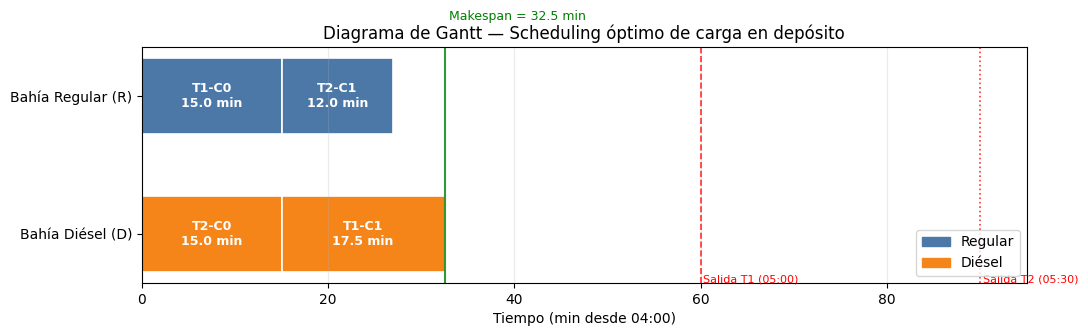

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Diagrama de Gantt — datos del cronograma óptimo (sin solver)
gantt_data = [
    ('Bahía Regular (R)', 'T1-C0', 0, 15, '#4C78A8'),
    ('Bahía Regular (R)', 'T2-C1', 15, 27, '#4C78A8'),
    ('Bahía Diésel (D)',  'T2-C0', 0, 15, '#F58518'),
    ('Bahía Diésel (D)',  'T1-C1', 15, 32.5, '#F58518'),
]

fig, ax = plt.subplots(figsize=(11, 3.5))
bay_rows = {'Bahía Regular (R)': 0, 'Bahía Diésel (D)': 1}

for bahia, op, start, end, color in gantt_data:
    row = bay_rows[bahia]
    ax.barh(row, end - start, left=start, height=0.55, color=color,
            edgecolor='white', linewidth=1.2)
    ax.text(start + (end - start) / 2, row, f'{op}\n{end-start:.1f} min',
            ha='center', va='center', color='white', fontsize=9, fontweight='bold')

ax.axvline(60, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(60.3, 1.35, 'Salida T1 (05:00)', color='red', fontsize=8)
ax.axvline(90, color='red', linestyle=':', linewidth=1.2, alpha=0.8)
ax.text(90.3, 1.35, 'Salida T2 (05:30)', color='red', fontsize=8)
ax.axvline(32.5, color='green', linewidth=1.5, alpha=0.8)
ax.text(33, -0.55, 'Makespan = 32.5 min', color='green', fontsize=9)

ax.set_yticks([0, 1])
ax.set_yticklabels(['Bahía Regular (R)', 'Bahía Diésel (D)'])
ax.set_xlabel('Tiempo (min desde 04:00)')
ax.set_title('Diagrama de Gantt — Scheduling óptimo de carga en depósito')
ax.set_xlim(0, 95)
ax.grid(axis='x', alpha=0.25)
ax.invert_yaxis()
ax.legend(handles=[mpatches.Patch(color='#4C78A8', label='Regular'),
                   mpatches.Patch(color='#F58518', label='Diésel')], loc='lower right')
plt.tight_layout()
plt.show()

###**3.- Análisis de soluciones propuestas**

**a) Factibilidad:**

a.1) Capacidad de compartimentos.

> Fórmula: $$\text{fill ratio} = \frac{L_{kc}}{Cap_{kc}}$$

Para cada compartimento por camión:

| Camión | Compart. | Producto | Carga (L) | Capacidad (L) | ¿Cabe? |
|--------|----------|----------|-----------|---------------|--------|
| T1 | C0 | Regular | 5,000 | 8,000 | Sí |
| T1 | C1 | Diésel | 5,000 | 7,000 | Sí |
| T2 | C0 | Diésel | 4,000 | 6,000 | Sí |
| T2 | C1 | Regular | 3,500 | 9,000 | Sí |

a.2) Restriccion de estabilidad.

 >Camión T1
| Instante | Inv. C0 | Inv. C1 | Fill C0 | Fill C1 | \|Δ\| | ¿Cumple? |
|----------|---------|---------|---------|---------|-------|----------|
| Salida depósito | 5,000 | 5,000 | 0.625 | 0.714 | 0.089 | Sí |
| Tras est. 1 | 2,000 | 3,000 | 0.250 | 0.429 | 0.179 | Sí |
| Tras est. 3 | 0 | 0 | 0 | 0 | 0 | Sí |

camion T2
| Instante | Inv. C0 | Inv. C1 | Fill C0 | Fill C1 | \|Δ\| | ¿Cumple? |
|----------|---------|---------|---------|---------|-------|----------|
| Salida depósito | 4,000 | 3,500 | 0.667 | 0.389 | 0.278 | Sí |
| Tras est. 2 | 2,500 | 0 | 0.417 | 0 | 0.417 | **NO** |
| Tras est. 4 | 0 | 0 | 0 | 0 | 0 | Sí |

a.3) ventanas de tiempo

Velocidad 60 km/h, servicio 30 min. Si llega antes de $a_j$, espera.

### Camión T1 (sale 05:00)

| Tramo | Dist (km) | Llegada | Ventana | Inicio servicio | ¿Cumple? |
|-------|-----------|---------|---------|-----------------|----------|
| D → 1 | 20 | 05:20 | [06:00–10:00] | 06:00 (espera) | Sí |
| 1 → 3 | 25 | 06:55 | [08:00–14:00] | 08:00 (espera) | Sí |

### Camión T2 (sale 05:30)

| Tramo | Dist (km) | Llegada | Ventana | Inicio servicio | ¿Cumple? |
|-------|-----------|---------|---------|-----------------|----------|
| D → 2 | 35 | 06:05 | [07:00–12:00] | 07:00 (espera) | Sí |
| 2 → 4 | 15 | 07:45 | [06:00–11:00] | 07:45 | Sí |




**b) Verificación del costo declarado**

$$Z = Z^{dist} + Z^{fijo} + Z^{short}$$

### Distancia

| Camión | Ruta | Cálculo (km) | Total |
|--------|------|--------------|-------|
| T1 | D→1→3→D | 20 + 25 + 15 | 60 |
| T2 | D→2→4→D | 35 + 15 + 40 | 90 |
| **Total** | | | **150 km** |

$Z^{dist} = 150 \times 2 = \$300$ (operador declaró \$260 → **error**)

### Costos fijos

$Z^{fijo} = 500 + 400 = \$900$ ✓

### Shortage

$Z^{short} = 2{,}000 \times 10 = \$20{,}000$ (operador declaró \$0 → **error**)

### Comparación

| Concepto | Operador declara | Cálculo real |
|----------|------------------|--------------|
| Distancia | \$260 | \$300 |
| Fijos | \$900 | \$900 |
| Shortage | \$0 | \$20,000 |
| **TOTAL** | **\$1,160** | **\$21,200** |

**c) Propuesta de mejora**

### Estabilidad T2 con ruta 4→2

| Instante | Fill C0 | Fill C1 | \|Δ\| | ¿Cumple? |
|----------|---------|---------|-------|----------|
| Salida depósito | 0.667 | 0.389 | 0.278 | Sí |
| Tras est. 4 | 0.250 | 0.278 | 0.028 | Sí |
| Tras est. 2 | 0 | 0 | 0 | Sí |

Ventanas y capacidades se mantienen.

### Comparación final

| | Operador | Mejora (T2: 4→2) |
|---|----------|------------------|
| Factible (Δ) | No | Sí |
| Distancia | 300 | 300 |
| Shortage | 20,000 | 20,000 |
| **Total** | **21,200** | **21,200** |

###**4. MODELO ESTOCÁSTICO**

## Escenarios de demanda

- **Est. 4:** Regular = 1,000 L y Diésel = 2,500 L en **todos** los escenarios.  
- **Est. 3:** varía la demanda de **Regular**; Diésel se mantiene en 3,000 L (valor del contexto base).  
- **Est. 1 y 2:** varían ambos productos.

### Probabilidades

| Escenario $s$ | Nombre | $\pi_s$ |
|---------------|--------|---------|
| 1 | Normal | 0.5 |
| 2 | Alta | 0.3 |
| 3 | Baja | 0.2 |
| | **Total** | **1.0** |

### Demanda $Dem_{jgs}$ (litros)

| $s$ | Est. | Regular | Diésel |
|-----|------|---------|--------|
| 1 | 1 | 3,000 | 2,000 |
| 1 | 2 | 4,000 | 1,500 |
| 1 | 3 | 2,500 | 3,000 |
| 1 | 4 | 1,000 | 2,500 |
| 2 | 1 | 4,500 | 2,800 |
| 2 | 2 | 5,500 | 2,000 |
| 2 | 3 | 3,500 | 3,000 |
| 2 | 4 | 1,000 | 2,500 |
| 3 | 1 | 2,000 | 1,200 |
| 3 | 2 | 3,000 | 1,000 |
| 3 | 3 | 1,800 | 3,000 |
| 3 | 4 | 1,000 | 2,500 |

### Totales por escenario

| Escenario | Demanda R (L) | Demanda D (L) | Total (L) |
|-----------|---------------|---------------|-----------|
| s=1 (Normal) | 10,500 | 9,000 | 19,500 |
| s=2 (Alta) | 14,500 | 10,300 | 24,800 |
| s=3 (Baja) | 7,800 | 7,700 | 15,500 |

---
## a) Modelo estocástico de dos etapas

### Conjuntos adicionales

| Símbolo | Definición |
|---------|------------|
| S = \{1,2,3\} | Escenarios (Normal, Alta, Baja) |
| $\pi_s$ | Probabilidad del escenario $s$, con $\sum_{s \in S} \pi_s = 1$ |
| $Dem_{jgs}$ | Demanda de producto $g$ en estación $j$ bajo escenario $s$ |

Se conservan los conjuntos de la P1: $V$, $K$, $C$, $G=\{R,D\}$, $A$, $J_2$.

## decisiones de la primera etapa
Se toman **antes** de conocer el escenario $s$. **No dependen de $s$** (regla de no anticipación).

| Variable | Tipo | Interpretación |
|----------|------|----------------|
| $util_k$ | Binaria | Usar camión $k$ |
| $x_{ijk}$ | Binaria | Camión $k$ recorre arco $(i,j)$ |
| $y_{kj}$ | Binaria | Camión $k$ visita estación $j$ |
| $trans_{kcg}$ | Binaria | Compartimento $(k,c)$ transporta producto $g$ |
| $L_{kc}$ | Continua $\geq 0$ | Carga inicial al salir del depósito |
| $T_{kj}$ | Continua $\geq 0$ | Tiempo de llegada del camión $k$ al nodo $j$ |
| $\sigma_{kj_1j_2}$ | Binaria | Orden de visita: $j_1$ antes que $j_2$ |



## Decisiones de la segunda etapa
Se toman **después** de observar el escenario $s$. Llevan índice $s \in S$.

| Variable | Tipo | Interpretación |
|----------|------|----------------|
| $w_{kcjs}$ | Continua $\geq 0$ | Litros entregados por $(k,c)$ en estación $j$ bajo $s$ |
| $\lambda_{kcjgs}$ | Continua $\geq 0$ | Litros de producto $g$ entregados (linearización) bajo $s$ |
| $s_{jgs}$ | Continua $\geq 0$ | Shortage de producto $g$ en estación $j$ bajo $s$ |
| $r_{kcjs}$ | Continua $\geq 0$ | Inventario remanente tras servir $j$ bajo $s$ |
| $\vartheta_{kj'js}$ | Continua $\geq 0$ | Auxiliar de linearización del orden de entrega bajo $s$ |

---
## Función objetivo estocástica


En la P1 (determinista):

$$
\min Z = Z^{dist} + Z^{fijo} + Z^{short}
$$

En la P4 (estocástica), los costos de **distancia** y **fijos** son de 1ª etapa (iguales para todo $s$). El **shortage** depende del escenario. Se minimiza el **costo esperado**:

$$
\min \; \mathbb{E}_s[Z] = Z^{dist} + Z^{fijo} + \sum_{s \in S} \pi_s \, Z^{short}_s
$$

donde:

$$
Z^{dist} = c^{dist} \sum_{k \in K} \sum_{(i,j) \in A} d_{ij}\, x_{ijk}
\qquad \text{(1ª etapa — sin índice } s\text{)}
$$

$$
Z^{fijo} = \sum_{k \in K} F_k\, util_k
\qquad \text{(1ª etapa)}
$$

$$
Z^{short}_s = c^{short} \sum_{j \in J} \sum_{g \in G} s_{jgs}
\qquad \text{(2ª etapa — indexada por escenario)}
$$

**Cambio respecto a P1:** solo el componente de shortage pasa a **valor esperado ponderado** por $\pi_s$. La estructura de costos es la misma, pero $s_{jp}$ se reemplaza por $s_{jps}$ y se suma $\sum_s \pi_s \, (\cdot)$.

| Componente | P1 (determinista) | P4 (estocástico) |
|------------|-------------------|------------------|
| Distancia | $Z^{dist}$ | Igual (sin $s$) |
| Fijos | $Z^{fijo}$ | Igual (sin $s$) |
| Shortage | $Z^{short} = c^{short}\sum_{j,p} s_{jp}$ | $\sum_s \pi_s \, Z^{short}_s$ con $s_{jps}$ |

## Restricciones por etapa

Son las mismas de la P1, pues no dependen de la demanda realizada:

| Grupo | Restricciones | Etapa |
|-------|---------------|-------|
| **Routing** | Activación de camiones, conservación de flujo | 1ª |
| **Tiempos** | MTZ, ventanas $[a_j, b_j]$ | 1ª |
| **Producto** | $\sum_g trans_{kcg} = 1$ (un producto por compartimento) | 1ª |
| **Capacidad** | $L_{kc} \leq Cap_{kc}$ | 1ª |
| **Orden** | Variables $\sigma_{kj_1j_2}$ y consistencia con $T_{kj}$ | 1ª |
| **Estabilidad depósito** | $\left|\frac{L_{kc}}{cap_{kc}}-\frac{L_{kc'}}{cap_{kc'}}\right|\leq\Delta$ al salir | 1ª |

Estas restricciones **sí dependen del escenario** porque modelan lo que ocurre **después** de conocer la demanda $Dem_{jgs}$:

| Grupo | Por qué es de 2ª etapa |
|-------|------------------------|
| **Balance de demanda** | El lado derecho es $Dem_{jgs}$, que cambia con $s$. En Alta se exige más litros; en Baja, menos. |
| **Linearización** | Vincula entregas $w_{kcjs}$ con producto; las cantidades varían según escenario. |
| **Inventario $r_{kcjs}$** | El remanente tras cada estación depende de cuánto se entregó en ese $s$. |
| **Estabilidad dinámica** | Se verifica tras cada entrega con inventarios $r_{kcjs}$, que son específicos de $s$. |